# JPEG Dataset Exploration

This notebook explores the PPMR dataset used in the deep contrastive metric learning paper.

## Dataset structure

```
data/PPMR/
├── PMGstudycaseslabelled/       ← 24 PMG patients (IDs: 2,3,4,5,...,34)
│   └── {pt}/
│       └── {pt}cor_1/           ← coronal MRI slices, one JPEG per slice
│           └── {pt}cor_1_{slice}_{label}.jpg
│
└── PMGControlsEditedDec2021/    ← same 24 IDs, healthy-control age-matched scans
    └── {pt}/
        ├── {pt}control1/        ← {pt}control1_cor_0_{slice}.jpg
        ├── {pt}control2/
        └── {pt}control3/
```

## Slice label convention

| Label | Where | Meaning |
|---|---|---|
| `0` | Controls folder | Control / healthy brain slice |
| `1` | PMG folder | **PMG found** — this slice shows polymicrogyria |
| `2` | PMG folder | **No PMG visible** — the patient has PMG, but this particular slice looks normal |
| `3` | PMG folder | **Uncertain / excluded** — ambiguous annotation, removed from all analyses |

> **Note:** The binary classification task is therefore:  
> Positive class = label **1** (PMG visible)  
> Negative class = label **0** (controls) + label **2** (no PMG visible in PMG patient)

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from natsort import natsorted
from collections import Counter

# ── Paths
BASE        = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'data', 'PPMR_light'))
PMG_DIR     = os.path.join(BASE, 'PMGcases')
CTRL_DIR    = os.path.join(BASE, 'controlcases')

print('PMG  dir:', PMG_DIR,  '→ exists:', os.path.isdir(PMG_DIR))
print('CTRL dir:', CTRL_DIR, '→ exists:', os.path.isdir(CTRL_DIR))

PMG  dir: /Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR_light/PMGcases → exists: True
CTRL dir: /Users/holgermaxfloelyng/Desktop/BioMed/MSc_Biomed/SEM_3/specialcourses/PMG/data/PPMR_light/controlcases → exists: True


---
## Data Overview

### Patient 22 is excluded
Patient 22's age-matched control scans are missing/corrupted in the **original** PPMR archive, making a properly paired comparison impossible. The patient's PMG folder data (scan + labels) exists in our processed copy, but the patient is excluded from all analyses to remain consistent with the original paper's methodology.

### Image resolution — a key confound

| Group | Typical resolution | Range |
|---|---|---|
| PMG cases | 1508 × 1727 px | All scans at this high resolution |
| Controls | 512 × 512 px (median) | 260 × 320 px → 512 × 512 px |

This **systematic resolution difference** is a potential confound: a trivial model could classify PMG vs. control based on image dimensions alone, without learning any pathological features.

---

In [5]:
# ── DATA OVERVIEW — three views of the dataset

# ─── 1. Scan all PMG slices and record per-patient label counts
_raw_pmg = []
for patient in natsorted(os.listdir(PMG_DIR)):
    pt_path = os.path.join(PMG_DIR, patient)
    sub = [d for d in os.listdir(pt_path) if 'cor' in d][0]
    for fname in os.listdir(os.path.join(pt_path, sub)):
        if not fname.lower().endswith('.jpg'):
            continue
        try:
            lbl = int(fname.split('.')[0].split('_')[3])
        except (IndexError, ValueError):
            continue
        _raw_pmg.append({'patient': int(patient), 'label': lbl})

# ─── 2. Scan all control slices
_raw_ctrl = []
for patient in natsorted(os.listdir(CTRL_DIR)):
    pt_path = os.path.join(CTRL_DIR, patient)
    for sub in os.listdir(pt_path):
        col = sub[len(patient):]
        n = len([f for f in os.listdir(os.path.join(pt_path, sub)) if f.lower().endswith('.jpg')])
        _raw_ctrl.append({'patient': int(patient), 'ctrl_group': col, 'n': n})

df_pmg_raw  = pd.DataFrame(_raw_pmg)
df_ctrl_raw = pd.DataFrame(_raw_ctrl)

print('PMG dataset overview:')
print(df_pmg_raw['label'].value_counts().sort_index())
print('\nControl dataset overview:')
print(df_ctrl_raw['ctrl_group'].value_counts().sort_index())



PMG dataset overview:
label
1    2255
2    1386
3     875
Name: count, dtype: int64

Control dataset overview:
ctrl_group
control1    24
control2    24
control3    24
Name: count, dtype: int64


In [6]:
_pmg_pivot = (
    df_pmg_raw.groupby(['patient', 'label']).size().unstack(fill_value=0)
    .rename(columns={1: 'PMG', 2: 'PMG-negative', 3: 'Uncertain'})
    .reset_index()
)
_ctrl_pivot = (
    df_ctrl_raw.groupby(['patient', 'ctrl_group'])['n'].sum().unstack(fill_value=0)
    .reset_index()
)

print(_pmg_pivot.head())
print(_ctrl_pivot.head())

label  patient  PMG  PMG-negative  Uncertain
0            2   35            97          9
1            3  158            54         16
2            4  145            25         10
3            5  133            25         12
4            6  122             0         18
ctrl_group  patient  control1  control2  control3
0                 2       198       125       138
1                 3       197       203       189
2                 4       120       113       119
3                 5       131       193       194
4                 6       136       198       196


In [7]:
# All df here contain label=3 (uncertain) slices
# check if PMG label columns exist; if not, add them with zero counts
for col in ['PMG', 'PMG-negative', 'Uncertain']:
    if col not in _pmg_pivot.columns:
        _pmg_pivot[col] = 0

# check if control columns exist; if not, add them with zero counts
for col in ['control1', 'control2', 'control3']:
    if col not in _ctrl_pivot.columns:
        _ctrl_pivot[col] = 0

# make sure all values are ints
_pmg_pivot[['PMG', 'PMG-negative', 'Uncertain']] = _pmg_pivot[['PMG', 'PMG-negative', 'Uncertain']].astype(int)
_ctrl_pivot[['control1', 'control2', 'control3']] = _ctrl_pivot[['control1', 'control2', 'control3']].astype(int)

# merge PMG normals with controls into a single negative class
_pmg = _pmg_pivot.merge(_ctrl_pivot, on='patient', how='outer').fillna(0).astype(int)


In [8]:
# make table A — all 24 patients, no exclusions
df_all = _pmg.copy()
df_all['uncertain'] = df_all['Uncertain']
df_all['PMG subject positive'] = df_all['PMG']
df_all['PMG subject negative'] = df_all['PMG-negative']
df_all['Control'] = df_all[['control1', 'control2', 'control3']].sum(axis=1)
df_all['Control + PMG-negative'] = df_all['PMG-negative'] + df_all['Control']
df_all['Total'] = df_all['PMG'] + df_all['PMG-negative'] + df_all['Control']
df_all['Inclusion status'] = df_all['patient'].apply(lambda x: 'Excluded' if x == 22 else 'Included')
# ensure int
df_all = df_all[['patient', 'uncertain', 'PMG subject positive', 'PMG subject negative', 'Control', 'Control + PMG-negative', 'Total', 'Inclusion status']]

In [9]:
# Display table A
print('TABLE A — All 24 patients, no exclusions')
print('--'*65)
# add a bottom line with totals

print(df_all.astype({'patient': str, 'uncertain': int, 'PMG subject positive': int, 'PMG subject negative': int, 'Control': int, 'Control + PMG-negative': int, 'Total': int, 'Inclusion status': str}).to_string(index=False))

# make table B — overview of totals
df_total = pd.DataFrame({
    'Category': ['Uncertain', 'PMG subject positive', 'PMG subject negative', 'Control + PMG-negative', 'Total (without label=3)', 'Total (with label=3)'],
    'Total slices': [
        df_all['uncertain'].sum(),
        df_all['PMG subject positive'].sum(),
        df_all['PMG subject negative'].sum(),
        df_all['Control + PMG-negative'].sum(),
        df_all['Total'].sum(),  # total excludes uncertain
        df_all['Total'].sum() + df_all['uncertain'].sum()  # total includes uncertain
    ]
})
print('\nTABLE B — Total slices per category (all 24 patients, no exclusions)')
print('--'*65)
print(df_total.to_string(index=False))


TABLE A — All 24 patients, no exclusions
----------------------------------------------------------------------------------------------------------------------------------
patient  uncertain  PMG subject positive  PMG subject negative  Control  Control + PMG-negative  Total Inclusion status
      2          9                    35                    97      461                     558    593         Included
      3         16                   158                    54      589                     643    801         Included
      4         10                   145                    25      352                     377    522         Included
      5         12                   133                    25      518                     543    676         Included
      6         18                   122                     0      530                     530    652         Included
      8         15                    51                   146      540                     686    737      

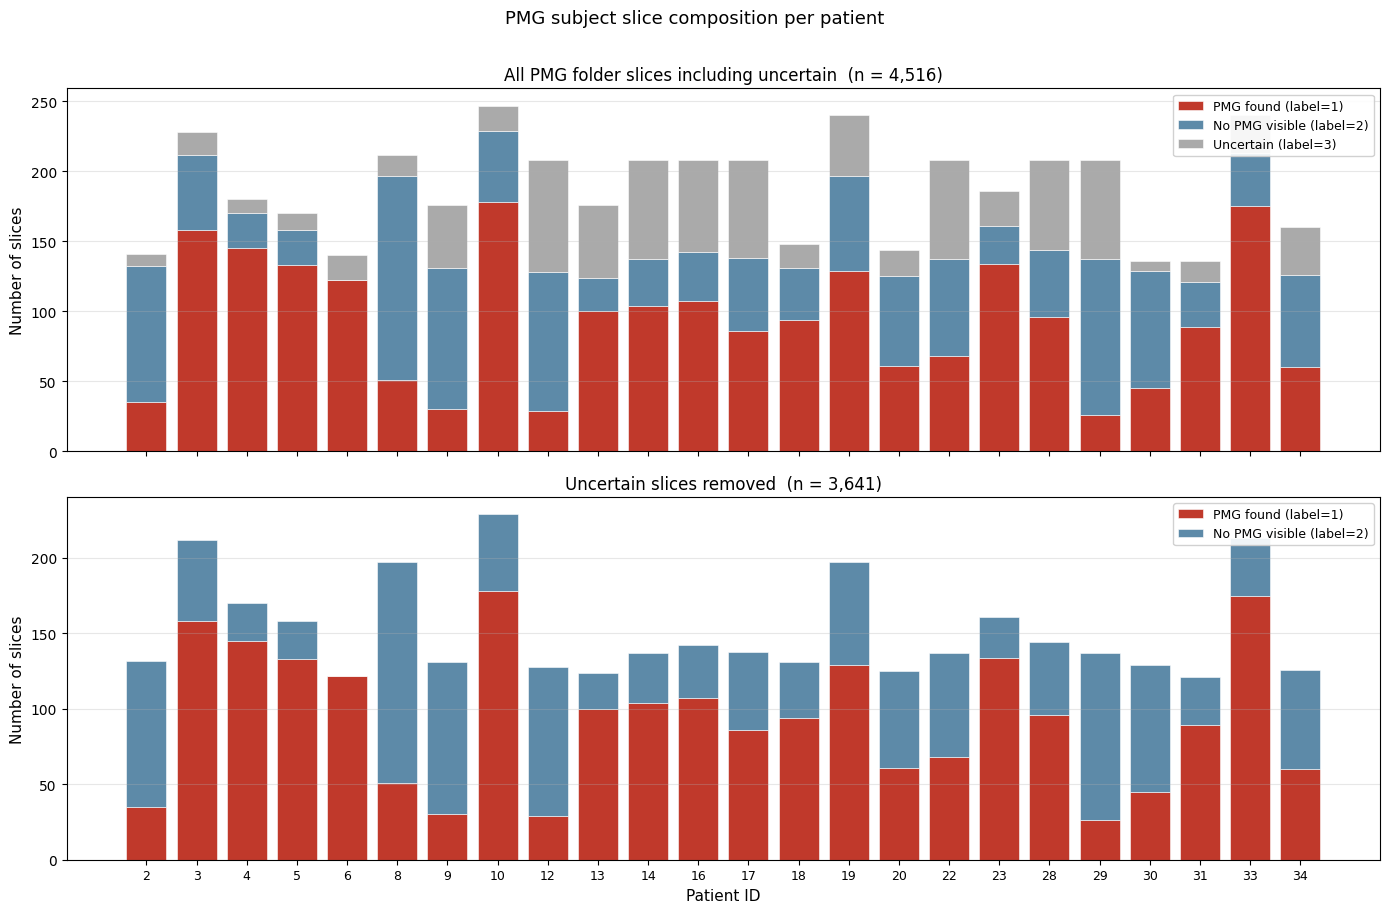

In [10]:
# ── Two PMG composition bars (top: all labels incl. uncertain; bottom: uncertain excluded)
# Saved as bar_pmgcases.png

PMG_COLS   = ['PMG subject positive', 'PMG subject negative', 'uncertain']
PMG_COLORS = ['#C0392B', '#5D8AA8', '#AAAAAA']
PMG_LABELS = ['PMG found (label=1)', 'No PMG visible (label=2)', 'Uncertain (label=3)']

patients = df_all['patient'].tolist()
x        = np.arange(len(patients))

n_all    = int(df_all[PMG_COLS].sum().sum())
n_no_unc = int(df_all[['PMG subject positive', 'PMG subject negative']].sum().sum())

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top: all three labels
bottom = np.zeros(len(patients))
for col, color, label in zip(PMG_COLS, PMG_COLORS, PMG_LABELS):
    vals = df_all[col].values
    axes[0].bar(x, vals, bottom=bottom, label=label, color=color,
                edgecolor='white', linewidth=0.4)
    bottom += vals
axes[0].set_ylabel('Number of slices', fontsize=11)
axes[0].set_title(f'All PMG folder slices including uncertain  (n = {n_all:,})', fontsize=12)
axes[0].legend(fontsize=9, loc='upper right', framealpha=0.9)
axes[0].grid(axis='y', alpha=0.3)

# ── Bottom: uncertain excluded
bottom = np.zeros(len(patients))
for col, color, label in zip(PMG_COLS[:2], PMG_COLORS[:2], PMG_LABELS[:2]):
    vals = df_all[col].values
    axes[1].bar(x, vals, bottom=bottom, label=label, color=color,
                edgecolor='white', linewidth=0.4)
    bottom += vals
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(p) for p in patients], fontsize=9)
axes[1].set_xlabel('Patient ID', fontsize=11)
axes[1].set_ylabel('Number of slices', fontsize=11)
axes[1].set_title(f'Uncertain slices removed  (n = {n_no_unc:,})', fontsize=12)
axes[1].legend(fontsize=9, loc='upper right', framealpha=0.9)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('PMG subject slice composition per patient', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/plots/bar_pmgcases.png', dpi=150, bbox_inches='tight')
plt.show()


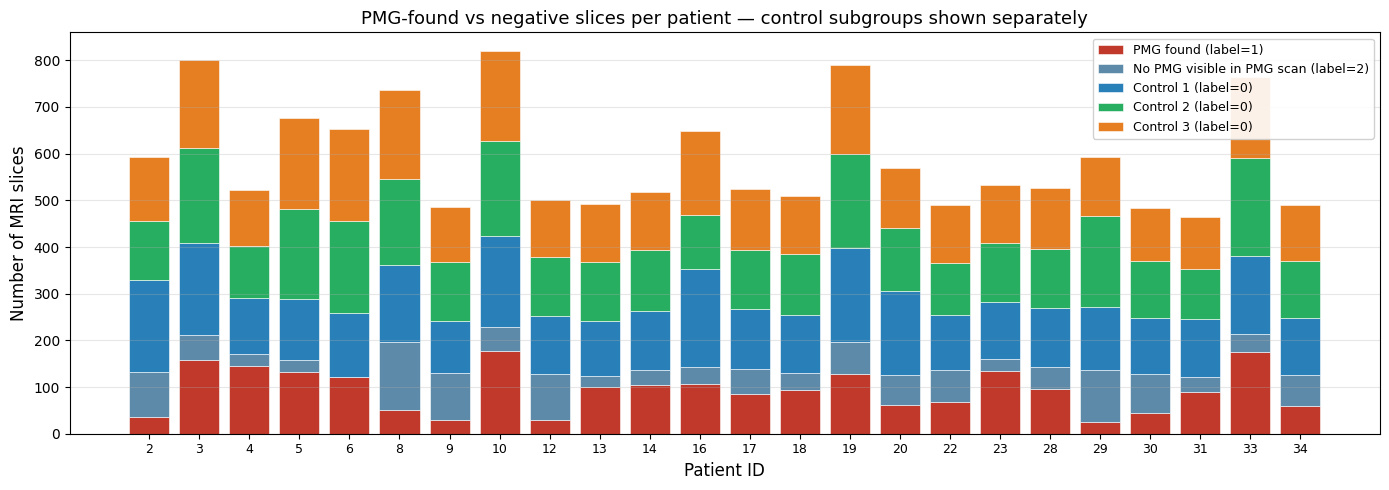

In [11]:
# ── Stacked bar per patient — PMG+, PMG-, ctrl1, ctrl2, ctrl3 (all 24 patients)
# Saved as barcolour_PMG+controls.png

STACK_COLORS_FULL = {
    'PMG':          ('#C0392B', 'PMG found (label=1)'),
    'PMG-negative': ('#5D8AA8', 'No PMG visible in PMG scan (label=2)'),
    'control1':     ('#2980B9', 'Control 1 (label=0)'),
    'control2':     ('#27AE60', 'Control 2 (label=0)'),
    'control3':     ('#E67E22', 'Control 3 (label=0)'),
}

pts_all = _pmg['patient'].tolist()
x_all   = np.arange(len(pts_all))

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(pts_all))

for col, (color, label) in STACK_COLORS_FULL.items():
    vals = _pmg[col].values
    ax.bar(x_all, vals, bottom=bottom, label=label, color=color,
           edgecolor='white', linewidth=0.4)
    bottom += vals

ax.set_xticks(x_all)
ax.set_xticklabels([str(p) for p in pts_all], fontsize=9)
ax.set_xlabel('Patient ID', fontsize=12)
ax.set_ylabel('Number of MRI slices', fontsize=12)
ax.set_title('PMG-found vs negative slices per patient — control subgroups shown separately', fontsize=13)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/barcolour_PMG+controls.png', dpi=150, bbox_inches='tight')
plt.show()


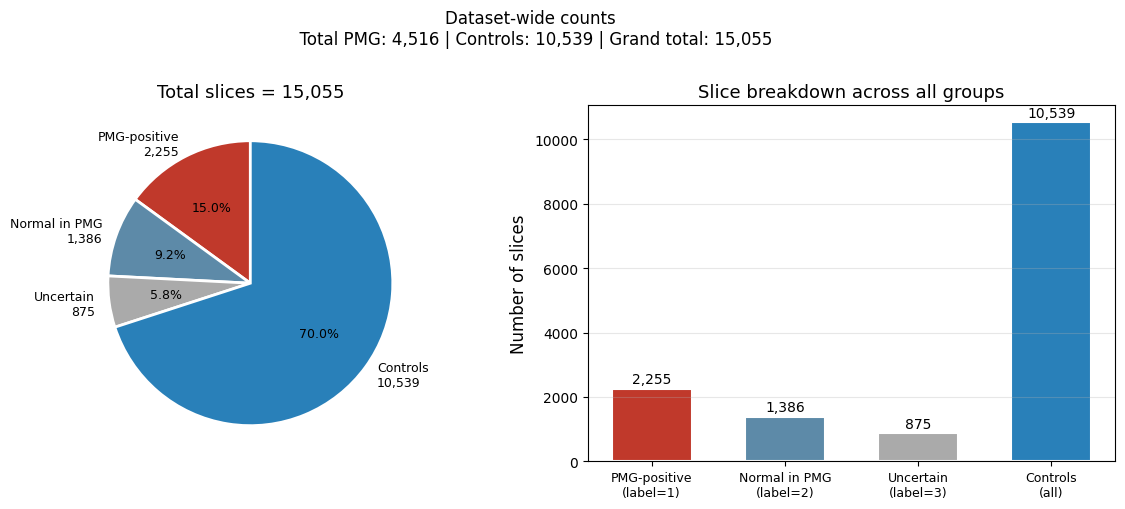

In [12]:
# ── bar_pmg+controls.png
# Pie (4-way: PMG+, PMG-, Uncertain, Controls) + bar (same 4 categories)

v_pos  = int(df_all['PMG subject positive'].sum())   # 2256
v_neg  = int(df_all['PMG subject negative'].sum())   # 1386
v_unc  = int(df_all['uncertain'].sum())               # 875
v_ctrl = int(df_all['Control'].sum())                 # 10539
grand  = v_pos + v_neg + v_unc + v_ctrl               # 15056

VALS4   = [v_pos, v_neg, v_unc, v_ctrl]
COLORS4 = ['#C0392B', '#5D8AA8', '#AAAAAA', '#2980B9']
LABS4   = ['PMG-positive', 'Normal in PMG', 'Uncertain', 'Controls']
XTICKS4 = ['PMG-positive\n(label=1)', 'Normal in PMG\n(label=2)',
           'Uncertain\n(label=3)', 'Controls\n(all)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(VALS4,
            labels=[f'{l}\n{v:,}' for l, v in zip(LABS4, VALS4)],
            colors=COLORS4, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f'Total slices = {grand:,}', fontsize=13)

for i, (val, color) in enumerate(zip(VALS4, COLORS4)):
    axes[1].bar(i, val, color=color, edgecolor='white', linewidth=1.5, width=0.6)
    axes[1].text(i, val + 80, f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(XTICKS4, fontsize=9)
axes[1].set_ylabel('Number of slices', fontsize=12)
axes[1].set_title('Slice breakdown across all groups', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Dataset-wide counts\n  Total PMG: {v_pos+v_neg+v_unc:,} | Controls: {v_ctrl:,} | Grand total: {grand:,}',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig('../results/plots/bar_pmg+controls.png', dpi=150, bbox_inches='tight')
plt.show()


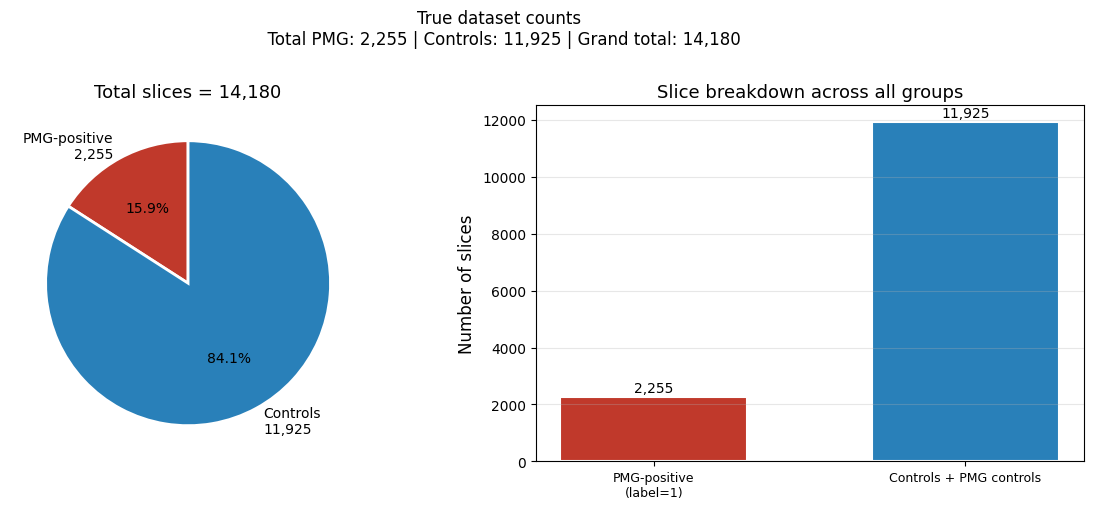

In [13]:
# ── true_dist_bar_pmg+controls.png
# Binary pie + bar: PMG found vs Controls + No-PMG-visible (uncertain removed, n=14,181)

v_pos2   = int(df_all['PMG subject positive'].sum())        # 2256
v_neg2   = int(df_all['Control + PMG-negative'].sum())      # 11925
total2   = v_pos2 + v_neg2                                  # 14181

VALS2   = [v_pos2, v_neg2]
COLORS2 = ['#C0392B', '#2980B9']
LABS2   = [f'PMG-positive\n{v_pos2:,}', f'Controls\n{v_neg2:,}']
XTICK2  = ['PMG-positive\n(label=1)', 'Controls + PMG controls']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(VALS2, labels=LABS2, colors=COLORS2,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 10},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f'Total slices = {total2:,}', fontsize=13)

for i, (val, color) in enumerate(zip(VALS2, COLORS2)):
    axes[1].bar(i, val, color=color, edgecolor='white', linewidth=1.5, width=0.6)
    axes[1].text(i, val + 80, f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[1].set_xticks(range(2))
axes[1].set_xticklabels(XTICK2, fontsize=9)
axes[1].set_ylabel('Number of slices', fontsize=12)
axes[1].set_title('Slice breakdown across all groups', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'True dataset counts\n  Total PMG: {v_pos2:,} | Controls: {v_neg2:,} | Grand total: {total2:,}',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig('../results/plots/true_dist_bar_pmg+controls.png', dpi=150, bbox_inches='tight')
plt.show()


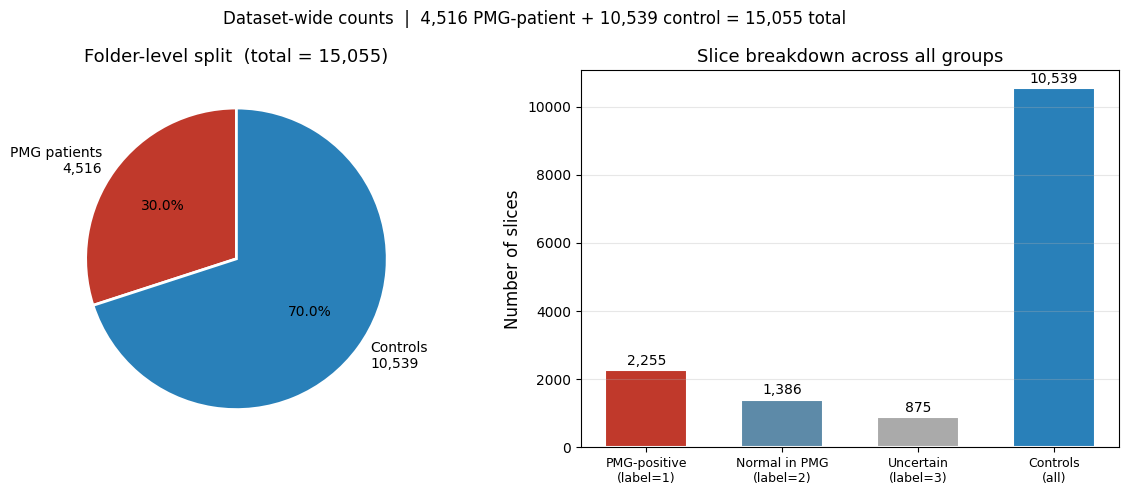

In [14]:
# ── piedesection.png
# Folder-level pie (PMG patients folder vs Controls folder) + label-breakdown bar

v_pos3  = int(df_all['PMG subject positive'].sum())   # 2256
v_neg3  = int(df_all['PMG subject negative'].sum())   # 1386
v_unc3  = int(df_all['uncertain'].sum())               # 875
v_ctrl3 = int(df_all['Control'].sum())                 # 10539

pmg_folder  = v_pos3 + v_neg3 + v_unc3   # 4517  (all slices from PMG patient scans)
ctrl_folder = v_ctrl3                     # 10539
grand3      = pmg_folder + ctrl_folder    # 15056

VALS_BAR = [v_pos3, v_neg3, v_unc3, v_ctrl3]
COLS_BAR = ['#C0392B', '#5D8AA8', '#AAAAAA', '#2980B9']
TICK_BAR = ['PMG-positive\n(label=1)', 'Normal in PMG\n(label=2)',
            'Uncertain\n(label=3)', 'Controls\n(all)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — folder-level pie
axes[0].pie(
    [pmg_folder, ctrl_folder],
    labels=[f'PMG patients\n{pmg_folder:,}', f'Controls\n{ctrl_folder:,}'],
    colors=['#C0392B', '#2980B9'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[0].set_title(f'Folder-level split  (total = {grand3:,})', fontsize=13)

# Right — per-label bar
for i, (val, color) in enumerate(zip(VALS_BAR, COLS_BAR)):
    axes[1].bar(i, val, color=color, edgecolor='white', linewidth=1.5, width=0.6)
    axes[1].text(i, val + 80, f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(TICK_BAR, fontsize=9)
axes[1].set_ylabel('Number of slices', fontsize=12)
axes[1].set_title('Slice breakdown across all groups', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Dataset-wide counts  |  {pmg_folder:,} PMG-patient + {ctrl_folder:,} control = {grand3:,} total',
    fontsize=12,
)
plt.tight_layout()
plt.savefig('../results/plots/piedesection.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 1  Image-size distribution

We load the width × height of every slice and group by:
- **PMG** (labelled cases)
- **control1 / control2 / control3** (healthy controls, three age-matched scans per patient)

In [15]:
records = []  # (width, height, group, patient_id)

# ── PMG cases 
for patient in tqdm(natsorted(os.listdir(PMG_DIR)), desc='PMG patients'):
    pt_path = os.path.join(PMG_DIR, patient)
    sub = [d for d in os.listdir(pt_path) if 'cor' in d][0]
    slice_dir = os.path.join(pt_path, sub)
    for fname in os.listdir(slice_dir):
        if not fname.lower().endswith('.jpg'):
            continue
        w, h = Image.open(os.path.join(slice_dir, fname)).size
        records.append({'width': w, 'height': h, 'group': 'PMG', 'patient': int(patient)})

# ── Controls 
for patient in tqdm(natsorted(os.listdir(CTRL_DIR)), desc='Control patients'):
    pt_path = os.path.join(CTRL_DIR, patient)
    for sub in sorted(os.listdir(pt_path)):
        group = sub[len(patient):]          # → 'control1', 'control2', 'control3'
        slice_dir = os.path.join(pt_path, sub)
        for fname in os.listdir(slice_dir):
            if not fname.lower().endswith('.jpg'):
                continue
            w, h = Image.open(os.path.join(slice_dir, fname)).size
            records.append({'width': w, 'height': h, 'group': group, 'patient': int(patient)})

df_sizes = pd.DataFrame(records)
print('Groups found:', sorted(df_sizes['group'].unique()))
print(df_sizes.groupby('group')[['width', 'height']].describe().round(0))

Control patients: 100%|██████████| 24/24 [00:01<00:00, 14.31it/s]

Groups found: ['PMG', 'control1', 'control2', 'control3']
           width                                                        \
           count    mean    std    min     25%     50%     75%     max   
group                                                                    
PMG       4517.0  1455.0  223.0  512.0  1508.0  1508.0  1508.0  1508.0   
control1  3498.0   409.0  121.0  208.0   260.0   512.0   512.0   512.0   
control2  3561.0   421.0  114.0  260.0   288.0   512.0   512.0   512.0   
control3  3480.0   421.0  118.0  260.0   260.0   512.0   512.0   512.0   

          height                                                        
           count    mean    std    min     25%     50%     75%     max  
group                                                                   
PMG       4517.0  1662.0  273.0  512.0  1727.0  1727.0  1727.0  1727.0  
control1  3498.0   426.0  100.0  256.0   320.0   512.0   512.0   512.0  
control2  3561.0   435.0   96.0  288.0   320.0   512.0   5

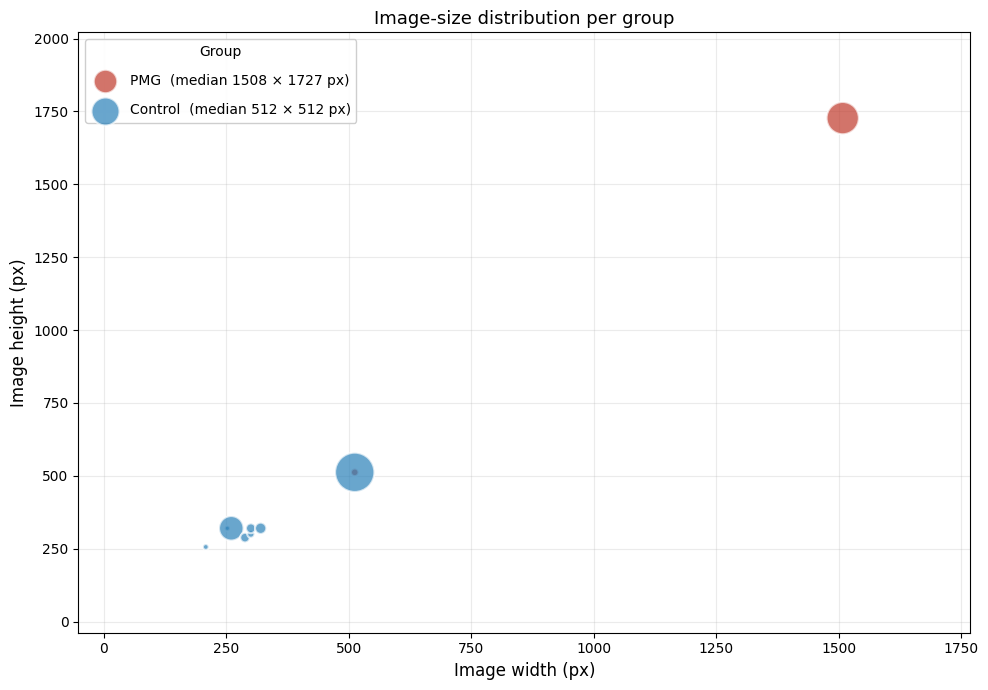

In [16]:
# Scatter plot — image-size distribution per group (linear scale)

df_plot = df_sizes.copy()
df_plot['group'] = df_plot['group'].replace({'control1': 'Control', 'control2': 'Control', 'control3': 'Control'})

GROUP_COLORS = {'PMG': '#C0392B', 'Control': '#2980B9'}

centroids = df_plot.groupby('group')[['width', 'height']].median().astype(int)

agg = (
    df_plot.groupby(['group', 'width', 'height'])
    .size().rename('n').reset_index()
)

MAX_BUBBLE = 800
global_max = agg['n'].max()

fig, ax = plt.subplots(figsize=(10, 7))

for group, color in GROUP_COLORS.items():
    sub = agg[agg['group'] == group]
    if sub.empty:
        continue
    cw, ch = centroids.loc[group, 'width'], centroids.loc[group, 'height']
    sizes = (sub['n'] / global_max) * MAX_BUBBLE
    ax.scatter(sub['width'], sub['height'], s=sizes, c=color, alpha=0.70,
               edgecolors='white', linewidth=1.5,
               label=f'{group}  (median {cw} × {ch} px)', zorder=3)

ax.set_xlabel('Image width (px)', fontsize=12)
ax.set_ylabel('Image height (px)', fontsize=12)
ax.set_title('Image-size distribution per group', fontsize=13)
ax.legend(title='Group', fontsize=10, title_fontsize=10,
          framealpha=0.95, loc='upper left', scatterpoints=1, labelspacing=1.1)
ax.grid(True, alpha=0.25)
ax.margins(0.2)
plt.tight_layout()
plt.savefig('../results/plots/scatter.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2  PMG subject slice composition

Two stacked bar charts showing per-patient slice breakdown within the PMG folder:

- **Top:** all three labels (PMG found / No PMG visible / Uncertain)
- **Bottom:** uncertain slices removed — only the two analysis-ready labels

Shaded bars = patient 22 (excluded from all analyses).

---
## Summary

### Label convention

| Label | Folder | Meaning | Role in classifier |
|---|---|---|---|
| `0` | Controls | Healthy brain slice | Negative class |
| `1` | PMG cases | **PMG found** — this slice shows polymicrogyria | Positive class |
| `2` | PMG cases | **No PMG visible** — PMG patient scan, this slice looks normal | Negative class |
| `3` | PMG cases | **Uncertain / excluded** — ambiguous annotation | Removed entirely |

### Key observations
- All PMG-patient slices are at **1508 × 1727 px**; controls vary (260×320 → 512×512) — a potential confound.
- The overall class imbalance (negative:positive) is roughly **~8:1**.
- Label=3 (uncertain) accounts for ~19% of PMG-patient slices and could represent boundary/transition zones.

---
## 5  Preprocessing comparison — Original vs Minimal

For 4 PMG and 4 control patients we show the representative middle slice before and after the **minimal** preprocessing preset (the only preset currently applied to the data).

> When additional presets are generated, add them to `PRESET` / `COL_TITLES` / `COL_KEYS` in the cell below.

In [17]:
import glob as _glob
from pathlib import Path

# ── Paths to raw (original) data
RAW_BASE     = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'data', 'PPMR'))
RAW_PMG_DIR  = os.path.join(RAW_BASE, 'PMGstudycaseslabelled')
RAW_CTRL_DIR = os.path.join(RAW_BASE, 'PMGControlsEditedDec2021')

# Only 'minimal' preset currently exists in the processed data
PRESET      = 'minimal'
COL_TITLES  = ['Original', 'Preprocessed (minimal)']
N_PATIENTS  = 4


# ── Helpers

def get_middle_slice(pt_dir: str) -> str | None:
    """Return the middle slice path (natsorted) for a given patient dir."""
    slices = natsorted(
        _glob.glob(os.path.join(pt_dir, '**', f'*_preprocessed_{PRESET}.jpg'), recursive=True)
    )
    return slices[len(slices) // 2] if slices else None


def get_original(preprocessed_path: str) -> Path | None:
    """Given a preprocessed path, find the matching original in the raw dirs."""
    base_stem = Path(preprocessed_path).stem.rsplit(f'_preprocessed_{PRESET}', 1)[0]
    hits = (
        _glob.glob(os.path.join(RAW_PMG_DIR,  '**', f'{base_stem}.jpg'), recursive=True) +
        _glob.glob(os.path.join(RAW_CTRL_DIR, '**', f'{base_stem}.jpg'), recursive=True)
    )
    return Path(hits[0]) if hits else None


# ── Collect one representative slice per patient

def collect_patients(proc_dir: str, n: int) -> list[dict]:
    rows = []
    for pt in natsorted(os.listdir(proc_dir))[:n]:
        pt_path  = os.path.join(proc_dir, pt)
        proc_path = get_middle_slice(pt_path)
        if proc_path is None:
            continue
        rows.append({
            'patient_id': pt,
            'original':   get_original(proc_path),
            'minimal':    Path(proc_path),
        })
    return rows

pmg_rows  = collect_patients(PMG_DIR,  N_PATIENTS)
ctrl_rows = collect_patients(CTRL_DIR, N_PATIENTS)

print(f'PMG patients collected : {[r["patient_id"] for r in pmg_rows]}')
print(f'Control patients       : {[r["patient_id"] for r in ctrl_rows]}')


# ── Plot

COL_KEYS = ['original', 'minimal']
all_rows  = pmg_rows + ctrl_rows
N_ROWS    = len(all_rows)
N_COLS    = len(COL_KEYS)

PMG_COLOR  = '#C0392B'
CTRL_COLOR = '#2980B9'

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 4, N_ROWS * 3.2))

for row_idx, row in enumerate(all_rows):
    is_pmg    = row_idx < N_PATIENTS
    pt_label  = f"{'PMG' if is_pmg else 'Ctrl'} {row['patient_id']}"
    row_color = PMG_COLOR if is_pmg else CTRL_COLOR

    for col_idx, (key, title) in enumerate(zip(COL_KEYS, COL_TITLES)):
        ax       = axes[row_idx, col_idx]
        img_path = row.get(key)

        if img_path is not None and Path(img_path).exists():
            ax.imshow(Image.open(img_path).convert('L'), cmap='gray', aspect='equal')
        else:
            ax.text(0.5, 0.5, 'not found', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='red')

        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(title, fontsize=12, fontweight='bold', pad=6)
        if col_idx == 0:
            ax.set_ylabel(pt_label, fontsize=10, color=row_color,
                          fontweight='bold', labelpad=6)

# Divider between PMG and Control blocks
fig.add_artist(plt.Line2D(
    [0.02, 0.98],
    [1 - N_PATIENTS / N_ROWS, 1 - N_PATIENTS / N_ROWS],
    transform=fig.transFigure, color='#555555', linewidth=1.5, linestyle='--',
))

fig.text(0.005, 1 - (N_PATIENTS / 2) / N_ROWS,
         'PMG', va='center', ha='left', fontsize=13,
         fontweight='bold', color=PMG_COLOR, rotation=90)
fig.text(0.005, 1 - (N_PATIENTS + N_PATIENTS / 2) / N_ROWS,
         'Control', va='center', ha='left', fontsize=13,
         fontweight='bold', color=CTRL_COLOR, rotation=90)

fig.suptitle('Preprocessing comparison — original vs minimal preset\n(middle slice per patient)',
             fontsize=14, y=1.01)
# Create output directory if it doesn't exist
output_dir = Path.cwd().parent / 'results' / 'plots'
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / 'preprocessing_comparison.svg', dpi=200, bbox_inches='tight')

plt.tight_layout(h_pad=0.4, w_pad=0.3)
plt.show()


PMG patients collected : []
Control patients       : []


ValueError: Number of rows must be a positive integer, not 0

<Figure size 800x0 with 0 Axes>